In [142]:
!pip install pandas numpy matplotlib seaborn
!pip install mne scipy jupyter
!pip install PyQt6

In [143]:
import os
import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt
from mne.datasets import eegbci

mne.viz.set_browser_backend("qt")

'qt'

## Load data

In [144]:
# Code partially obtained from dataset documentation: https://data-brain-mind.github.io/tutorials/reading-observed-at-mindless-moments-roamm-a-simultaneous-eeg-and-eye-tracking-dataset-of-natural-reading-with-attention-annotations/
# define data root
# this is the path to the ROAMM folder on local machine
roamm_root = r"./data"
ml_data_root = os.path.join(roamm_root, 'subject_ml_data')

In [145]:
# Select one subject and run number to test with
subject_id = 's10014'
subject_dir = os.path.join(ml_data_root, subject_id)
run_number = 1
df_run = pd.read_pickle(os.path.join(subject_dir, f'{subject_id}_run{run_number}_ml_data.pkl')) # Load that file
df_run_filtered = df_run[df_run.first_pass_reading==True] # Filter for only data points where the participant is actually reading the text (not reading instructions or performing a MW check)

# Channels to filter for later
EEG_cols = ['Fp1',  'AF7',  'AF3',  'F1',  'F3',  'F5',  'F7',  'FT7',  'FC5',  'FC3',  'FC1',  'C1',  'C3',  'C5',  'T7',  'TP7',  'CP5',  'CP3',  'CP1',  'P1',  'P3',  'P5',  'P7',  'P9',  'PO7',  'PO3',  'O1',  'Iz',  'Oz',  'POz',  'Pz',  'CPz',  'Fpz',  'Fp2',  'AF8',  'AF4',  'Afz',  'Fz',  'F2',  'F4',  'F6',  'F8',  'FT8',  'FC6',  'FC4',  'FC2',  'FCz',  'Cz',  'C2',  'C4',  'C6',  'T8',  'TP8',  'CP6',  'CP4',  'CP2',  'P2',  'P4',  'P6',  'P8',  'P10',  'PO8',  'PO4',  'O2']

# Relevant description columns
exp_cols = ['time','is_mw', 'mw_onset', 'mw_offset', 'mw_dur']

In [146]:
display(df_run_filtered[EEG_cols+exp_cols].head())
display([*df_run_filtered.columns])

,Fp1,AF7,AF3,F1,F3,F5,F7,FT7,FC5,FC3,...,P8,P10,PO8,PO4,O2,time,is_mw,mw_onset,mw_offset,mw_dur
3215,-0.000001,0.000001,-3.233485e-06,-0.000002,-3.570374e-06,-3.794776e-06,9.564145e-07,-0.000006,-6.211175e-07,4.306251e-07,...,6.385265e-06,-9.651197e-08,3.590585e-06,-0.000002,0.000002,12.558594,NaN,NaN,NaN,NaN
3216,0.000005,0.000001,9.098603e-08,0.000001,-7.429804e-07,-2.627195e-06,-2.663648e-06,-0.000008,-1.114337e-06,2.025536e-06,...,3.646609e-06,-2.481566e-06,-2.408371e-07,-0.000006,-0.000002,12.562500,NaN,NaN,NaN,NaN
3217,0.000010,0.000003,3.404914e-06,0.000002,2.027947e-06,-4.891517e-08,-2.246929e-06,-0.000006,-2.427471e-07,3.729228e-06,...,6.790179e-07,-1.695545e-06,-1.588166e-06,-0.000009,-0.000004,12.566406,NaN,NaN,NaN,NaN
3218,0.000010,0.000006,4.720883e-06,0.000002,3.039013e-06,2.077813e-06,2.598019e-06,-0.000002,2.181295e-06,4.819751e-06,...,-7.030773e-07,1.243187e-06,-4.147942e-08,-0.000009,-0.000004,12.570312,NaN,NaN,NaN,NaN
3219,0.000004,0.000008,3.584969e-06,0.000001,1.631473e-06,2.969682e-06,9.137543e-06,0.000003,5.203575e-06,4.801439e-06,...,-1.401352e-06,2.544503e-06,1.898883e-06,-0.000007,-0.000002,12.574219,NaN,NaN,NaN,NaN


['Fp1',
 'AF7',
 'AF3',
 'F1',
 'F3',
 'F5',
 'F7',
 'FT7',
 'FC5',
 'FC3',
 'FC1',
 'C1',
 'C3',
 'C5',
 'T7',
 'TP7',
 'CP5',
 'CP3',
 'CP1',
 'P1',
 'P3',
 'P5',
 'P7',
 'P9',
 'PO7',
 'PO3',
 'O1',
 'Iz',
 'Oz',
 'POz',
 'Pz',
 'CPz',
 'Fpz',
 'Fp2',
 'AF8',
 'AF4',
 'Afz',
 'Fz',
 'F2',
 'F4',
 'F6',
 'F8',
 'FT8',
 'FC6',
 'FC4',
 'FC2',
 'FCz',
 'Cz',
 'C2',
 'C4',
 'C6',
 'T8',
 'TP8',
 'CP6',
 'CP4',
 'CP2',
 'P2',
 'P4',
 'P6',
 'P8',
 'P10',
 'PO8',
 'PO4',
 'O2',
 'time',
 'sfreq',
 'first_pass_reading',
 'page_num',
 'page_start',
 'page_end',
 'page_dur',
 'is_mw',
 'mw_onset',
 'mw_offset',
 'mw_dur',
 'run_num',
 'story_name',
 'is_fix',
 'fix_L_eye',
 'fix_L_tStart',
 'fix_L_tEnd',
 'fix_L_duration',
 'fix_L_xAvg',
 'fix_L_yAvg',
 'fix_L_pupilAvg',
 'fix_L_fixed_word',
 'fix_L_fixed_word_key',
 'fix_R_eye',
 'fix_R_tStart',
 'fix_R_tEnd',
 'fix_R_duration',
 'fix_R_xAvg',
 'fix_R_yAvg',
 'fix_R_pupilAvg',
 'fix_R_fixed_word',
 'fix_R_fixed_word_key',
 'is_blink',
 'bli

### Create MNE Array object

In [147]:

eeg_data = df_run_filtered[EEG_cols+exp_cols]
eeg_data["is_mw"] = eeg_data["is_mw"].replace(np.nan, False) # Replace NaN with False in the MW column

eeg_dataT = eeg_data.values.T  # Transpose to (n_channels, n_samples)

# Create channel information
n_channels = eeg_dataT.shape[0]
ch_names = eeg_data.columns.tolist()  # Or specify your channel names
ch_types = ['eeg'] * n_channels  # All channels are EEG

# Create info object
info = mne.create_info(ch_names=ch_names, 
                       sfreq=256,  # Replace with your sampling frequency in Hz
                       ch_types=ch_types)

# Create Raw object
raw = mne.io.RawArray(eeg_dataT, info)

# Set channel types for experiment details
raw.set_channel_types({
    'time': 'syst',
    'is_mw': 'stim',
    'mw_onset': 'stim',
    'mw_offset': 'stim',
    'mw_dur': 'stim'
})

# Detect events and convert to annotations
events = mne.find_events(raw, stim_channel="is_mw")
print(events)

annot_from_events = mne.annotations_from_events(
    events=events,
    event_desc={0: "noMW", 1:"MW"},
    sfreq=raw.info["sfreq"],
    orig_time=raw.info["meas_date"],
)

# Add annotations
raw.set_annotations(annot_from_events)

Creating RawArray with float64 data, n_channels=69, n_times=54052
    Range : 0 ... 54051 =      0.000 ...   211.137 secs
Ready.
Finding events on: is_mw
10 events found on stim channel is_mw
Event IDs: [1]
[[ 1579     0     1]
 [13411     0     1]
 [16198     0     1]
 [25146     0     1]
 [30758     0     1]
 [32620     0     1]
 [35858     0     1]
 [39343     0     1]
 [44624     0     1]
 [50447     0     1]]


/tmp/ipykernel_39315/724557917.py:20: RuntimeWarning: The unit for channel(s) time has changed from V to NA.
  raw.set_channel_types({


<RawArray | 69 x 54052 (211.1 s), ~28.5 MiB, data loaded>

In [148]:
raw.annotations

<Annotations | 10 segments: MW (10)>

In [149]:
raw.plot()
plt.show()

In [150]:
eegbci.standardize(raw)
montage = mne.channels.make_standard_montage("biosemi64")
raw.set_montage(montage)

<RawArray | 69 x 54052 (211.1 s), ~28.5 MiB, data loaded>

### Make visualizations

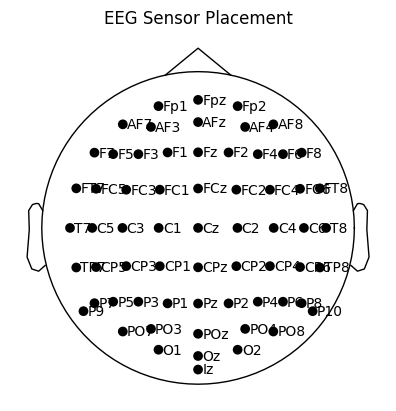

In [151]:
# EEG sensor placements
fig,ax = plt.subplots()
ax.set_title("EEG Sensor Placement")
raw.plot_sensors(show_names=True, axes=ax, kind='topomap', ch_type='eeg')
plt.show()

Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).


/home/stefan/Documents/GitHub/BCI-Mind-Wandering/.conda/lib/python3.11/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


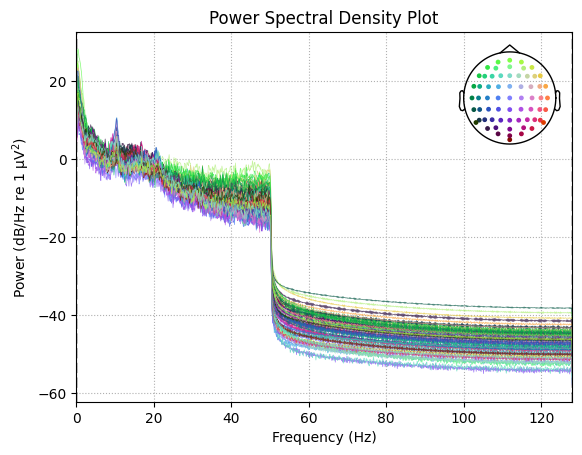

In [152]:
fig,ax = plt.subplots()
raw.compute_psd().plot(axes=ax)
ax.set_title("Power Spectral Density Plot")
plt.show()

Effective window size : 8.000 (s)


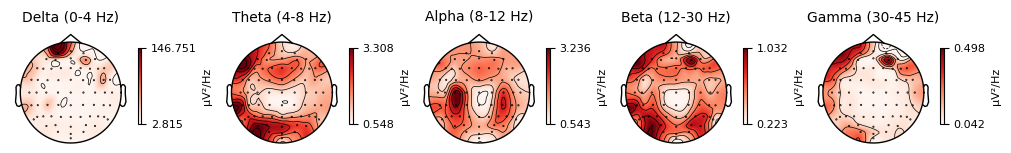

In [153]:
raw.compute_psd().plot_topomap()
plt.show()